# Tutorial 2.2 — Sea Surface Temperature and ENSO

In notebook 2.1 you found that the greenest parts of the ocean are where something brings deep water to the surface. Temperature is a large part of *why*: warm water floats on cold water and resists mixing with it, so how warm the surface is helps decide whether nutrients can reach the light.

**The plan:** get the three ENSO months (§2–3) → fix the units and the grid, and map them (§4–6) → the tropical Pacific, and the difference between ENSO phases (§7–9).

**Required from this notebook: section 8.** Assignment question 7 is answered from its figure and its two printed tables. Section 6 is optional and not marked.

You met Himawari itself in section 8 of notebook 2.1.

## Setting up

Run the cell below first, before anything else on this page.

Colab hands you a completely empty machine, so this cell installs the packages the tutorial needs, creates the folders the notebook writes into, and sets up `login()`, which the download cells use to get your data provider username and password out of your Colab Secrets.

Colab forgets everything between sessions, so run it again whenever you reopen the notebook.

In [1]:
# --- Setup: run this cell first. Safe to re-run. ---------------------------
# Colab gives you an empty machine and takes it back when the session ends,
# so this installs the packages the tutorial needs, and sets up how the
# download cells get your data provider logins. Run it again whenever you
# reopen the notebook.

import importlib
import importlib.util
import os
import subprocess
import sys

try:
    import google.colab               # noqa: F401 - importing it is the test
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REQUIRED = {                      # import name -> pip name
    "cartopy": "cartopy",
    "earthaccess": "earthaccess>=0.16",
    "h5netcdf": "h5netcdf",
    "matplotlib": "matplotlib",
    "netCDF4": "netCDF4",
    "numpy": "numpy",
    "requests": "requests",
    "xarray": "xarray",
}

missing = [spec for mod, spec in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]

if missing:
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                   check=False)
    importlib.invalidate_caches()

    # Check they import, rather than that pip said it was fine: a package can
    # install cleanly and still fail to load, and the fix for that is a
    # restart, which pip cannot do for you.
    broken = []
    for mod in REQUIRED:
        try:
            importlib.import_module(mod)
        except Exception as error:        # noqa: BLE001 - report anything
            broken.append(f"{mod} ({type(error).__name__}: {error})")

    if broken:
        print("\nInstalled, but these still will not import:")
        for line in broken:
            print("   ", line)
        print("Runtime -> Restart session, then run this cell again.")
    else:
        print("Ready.")
else:
    print("Ready - nothing to install.")

# --- Signing in ------------------------------------------------------------
# This defines `login()`. The download cells below call it when they need your
# username and password for a data provider; nothing is asked for here.
#
# It looks in **Colab Secrets** first - the key icon in the left sidebar. A
# secret belongs to your Google account rather than to this notebook, so you
# add it once and every tutorial in the course finds it. Turn on "Notebook
# access" for each. This tutorial asks for:
#
#     PTREE_USERNAME  and  PTREE_PASSWORD
#         your P-Tree FTP credentials - NOT your P-Tree website login
#
# There is no typing them in here instead. A notebook can read Secrets but
# cannot write them, so a password typed into a cell would be gone again next
# session - and saved into the notebook if you shared it. `login()` says what
# to add and where if a secret is missing.

CREDENTIALS = {            # what to call it -> secret names, and sign-up
    "JAXA P-Tree":
        ("PTREE_USERNAME", "PTREE_PASSWORD",
         "https://www.eorc.jaxa.jp/ptree/registration_top.html"),
}


def read_secret(name):
    """One Colab secret, or None if unset or not shared with this notebook."""
    if not IN_COLAB:
        return None
    try:
        from google.colab import userdata

        return (userdata.get(name) or "").strip() or None
    except Exception:                 # noqa: BLE001 - unset, or not shared
        return None


def login(provider):
    """The username and password for one data provider, from Colab Secrets.

    Nothing is typed into this notebook. Secrets are re-read on every call, so
    correcting one in the sidebar and running the cell again takes effect.
    """
    user_secret, pass_secret, register = CREDENTIALS[provider]
    user, password = read_secret(user_secret), read_secret(pass_secret)

    if not (user and password):
        raise RuntimeError(
            f"{provider}: {user_secret} and {pass_secret} are not readable.\n\n"
            "Open the key icon in the left sidebar - the Secrets tab - and for\n"
            "each of the two:\n"
            "    1. click + Add new secret\n"
            f"    2. put {user_secret} (then {pass_secret}) in Name\n"
            "    3. paste the value in Value\n"
            "    4. switch Notebook access on\n\n"
            "Then run this cell again. If they are already there, it is the\n"
            "Notebook access switch that is off for this notebook.\n\n"
            f"No account yet? Register at {register}")

    return user, password

Installing: cartopy, earthaccess>=0.16, netCDF4
Ready.


In [2]:
# --- Folders and the figure saver: run this after the setup cell above. ---
# The setup cell installed the packages. This one makes the folders the
# notebook writes into, and defines save_fig(). Safe to re-run.
import os
import warnings

# Downloads go in data/, figures in output/, both beside this notebook.
DATA_DIR = os.path.join(os.getcwd(), "data", "SSTraw")
FIG_DIR = os.path.join(os.getcwd(), "output", "figures")
for d in (DATA_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# Silence one harmless shapely warning that cartopy triggers on every map.
warnings.filterwarnings(
    "ignore", category=RuntimeWarning,
    message="invalid value encountered in create_collection")

# Turn off Jupyter's tight crop, which mangles cartopy maps into thin strips.
try:
    _shell = get_ipython()
except NameError:                      # not running under IPython
    _shell = None
if _shell is not None:
    _shell.run_line_magic(
        "config", "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")

# cartopy puts a title at an infinite y when an axes has labelled gridlines, so
# the title falls off the canvas and out of the saved PNG. Pin it to the top of
# the axes instead; harmless on ordinary plots.
import matplotlib as mpl

mpl.rcParams["axes.titley"] = 1.0
mpl.rcParams["axes.titlepad"] = 6


def save_fig(fig, name, dpi=200):
    """Write a figure to output/figures/ so you can put it in your Word document.

    On Colab, open the folder icon in the left sidebar, find the file, and
    use its three-dot menu to Download it. The runtime is thrown away when
    the session ends, so download what you need before you close the tab.
    """
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi)
    print("Saved figure:", os.path.relpath(path, os.getcwd()))
    return path

print("Data will be downloaded to:", DATA_DIR)
print("Figures will be saved to  :", FIG_DIR)

Data will be downloaded to: /content/data/SSTraw
Figures will be saved to  : /content/output/figures


## 1. A completely different kind of satellite

PACE orbits pole to pole, seeing a different strip of the world on each pass. Himawari-8 and Himawari-9 are **geostationary**: they sit above a fixed point on the equator, turning with the Earth, staring at the same disc continuously.

| | Polar orbit (PACE) | Geostationary (Himawari) |
|---|---|---|
| Coverage | The whole globe, eventually | One disc, and nothing outside it, ever |
| How often | Once every day or two | Every ten minutes |

The sea surface radiates in the **thermal infrared**, around 10–12 µm, where the atmosphere is fairly transparent. The AHI imager measures that radiation in two or three bands, and comparing the bands corrects for water vapour. Three consequences show up in your maps:

- **Clouds are opaque in the infrared.** A cloudy pixel is not a poor measurement, it is *no* measurement, hence the monthly composite of clear-sky views.
- **It measures the *skin* of the ocean**, the top fraction of a millimetre.
- **Coverage stops at the edge of the disc**, roughly **80°E to 160°W (200°E)**, so the eastern tropical Pacific is outside its view.

We use the **monthly Level-3 SST** product from AHI on a 0.02° grid.

> **The SST in these files is in Kelvin.** Section 4 deals with it.

## 2. Getting the three ENSO periods

This notebook works with **December 2022, December 2023 and July 2024**, one file for each phase of the ENSO cycle.

Run the cell below to download them. They are the same JAXA monthly Level-3 SST files you used in [section 8 of notebook 2.1](https://github.com/earthobservatory/eyes-on-earth-tutorials-public/blob/main/2.1_Ocean_Colour_with_PACE_OCI/2.1.1_PACE_OCI_Chlorophyll_a_colab.ipynb).

In [3]:
import requests

# The processed files for this tutorial.
COURSE_DATA = ("https://eyes-on-earth-tutorial-resources.s3.ap-southeast-1"
               ".amazonaws.com/tutorial_2/processed_data")


def download(url, dest_dir):
    """Download one file, skipping it if already there.

    Writes to a .part file first, so an interrupted download leaves nothing
    truncated behind.
    """
    name = url.split("/")[-1]
    dest = os.path.join(dest_dir, name)
    if os.path.exists(dest):
        print(f"Already have {name}")
        return dest

    tmp = dest + ".part"
    print(f"Downloading {name} ...", end=" ", flush=True)
    try:
        with requests.get(url, stream=True, timeout=600) as r:
            if r.status_code in (401, 403):
                raise PermissionError(
                    f"{r.status_code} from the course bucket for {name}. The "
                    "file is there but not readable without credentials - tell "
                    "your instructor, or get the file from them directly.")
            r.raise_for_status()
            with open(tmp, "wb") as fh:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    fh.write(chunk)
        os.replace(tmp, dest)
    except BaseException:
        if os.path.exists(tmp):
            os.remove(tmp)
        raise

    print(f"done ({os.path.getsize(dest) / 1e6:.0f} MB)")
    return dest

ENSO_SST = [
    "H09_20221201_0000_1MSST201_FLDK.06001_06001.nc",   # December 2022
    "H09_20231201_0000_1MSST201_FLDK.06001_06001.nc",   # December 2023
    "H09_20240701_0000_1MSST201_FLDK.06001_06001.nc",   # July 2024
]

for name in ENSO_SST:
    download(f"{COURSE_DATA}/Himawari_SST/{name}", DATA_DIR)

print("\nDone. Section 3 lists everything in", DATA_DIR)


Done. Section 3 lists everything in /content/data/SSTraw


## 3. Look inside the file

The first cell lists what you downloaded and prints the structure of the first file. The second picks out the temperature variable.

**Watch for two things**, both of which cause work in section 4: the **units** of `sea_surface_temperature`, and the **longitude range**.

In [4]:
import glob

import xarray as xr

paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
print("Files:", [os.path.basename(p) for p in paths])

ds = xr.open_dataset(paths[0])
ds

Files: ['H09_20221201_0000_1MSST201_FLDK.06001_06001.nc', 'H09_20231201_0000_1MSST201_FLDK.06001_06001.nc', 'H09_20240701_0000_1MSST201_FLDK.06001_06001.nc']


<xarray.Dataset> Size: 144MB
Dimensions:                  (lat: 6001, lon: 6001)
Coordinates:
  * lat                      (lat) float32 24kB 60.0 59.98 ... -59.98 -60.0
  * lon                      (lon) float32 24kB 80.0 80.02 ... -160.0 -160.0
Data variables:
    sea_surface_temperature  (lat, lon) float32 144MB ...
Attributes:
    processing_level:           L3C
    cdm_data_type:              grid
    spatial_resolution:         0.02 deg
    geospatial_lat_units:       degrees north
    geospatial_lat_resolution:  0.02
    geospatial_lon_units:       degrees east
    geospatial_lon_resolution:  0.02

In [5]:
sst_var = "sea_surface_temperature"
print(ds[sst_var])
print("\nUnits     :", ds[sst_var].attrs.get("units"))
print("Lat range :", float(ds.lat.min()), "to", float(ds.lat.max()))
print("Lon range :", float(ds.lon.min()), "to", float(ds.lon.max()))

<xarray.DataArray 'sea_surface_temperature' (lat: 6001, lon: 6001)> Size: 144MB
[36012001 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 24kB 60.0 59.98 59.96 59.94 ... -59.96 -59.98 -60.0
  * lon      (lon) float32 24kB 80.0 80.02 80.04 80.06 ... -160.0 -160.0 -160.0
Attributes:
    long_name:      sea surface skin temperature
    standard_name:  sea_surface_skin_temperature
    units:          kelvin
    valid_min:      -200
    valid_max:      5000
    grid_mapping:   Equirectangular
    comment:        Temperature of the skin of the ocean.

Units     : kelvin
Lat range : -60.0 to 60.0
Lon range : -179.98001098632812 to 180.0


## 4. Two things to fix before mapping

### Problem 1 — the temperature is in Kelvin

Subtract 273.15:

```python
sst = ds[sst_var] - 273.15
```

The cell also overwrites the `units` attribute, so the array stops claiming to be in Kelvin.

### Problem 2 — the longitudes run past 180°

The full disc runs from 80°E to **200°E**, which is 160°W, and 200°E sits outside the −180…180 range that map projections expect. Hand them a longitude of 200 and you get either an error or a silently wrong map.

For sections 4 to 6, which only map the Asia-Pacific, we throw away everything past 180°:

```python
sst.sel(lon=slice(80, 180))
```

The result is 30 million cells, which matters for the next section.

Section 7 needs the part beyond 180°, because the tropical Pacific crosses the antimeridian, and handles it differently.

In [6]:
sst = ds[sst_var] - 273.15               # Kelvin to Celsius
sst = sst.squeeze(drop=True)             # drop a length-1 time dimension if present
sst = sst.sel(lon=slice(80, 180))        # keep 80E to 180E only
sst.attrs["units"] = "degrees_Celsius"

print("Shape after crop:", sst.shape)
print("Lon range       :", float(sst.lon.min()), "to", float(sst.lon.max()))
print("Value range     :", float(sst.min()), "to", float(sst.max()), "degC")

Shape after crop: (6001, 5001)
Lon range       : 80.0 to 180.0
Value range     : -5.739990234375 to 32.779998779296875 degC


## 5. Mapping the SST

30 million cells is more than a figure can show, so `for_display()` subsamples to roughly two million by taking every nth point.

> **Subsampling changes the picture only.** It takes every nth point rather than averaging, so extremes shift slightly. Every number you report comes from the full-resolution array.

  subsampling 4x for display: (6001, 5001) -> (1501, 1251)


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved figure: output/figures/sst_full_disc.png


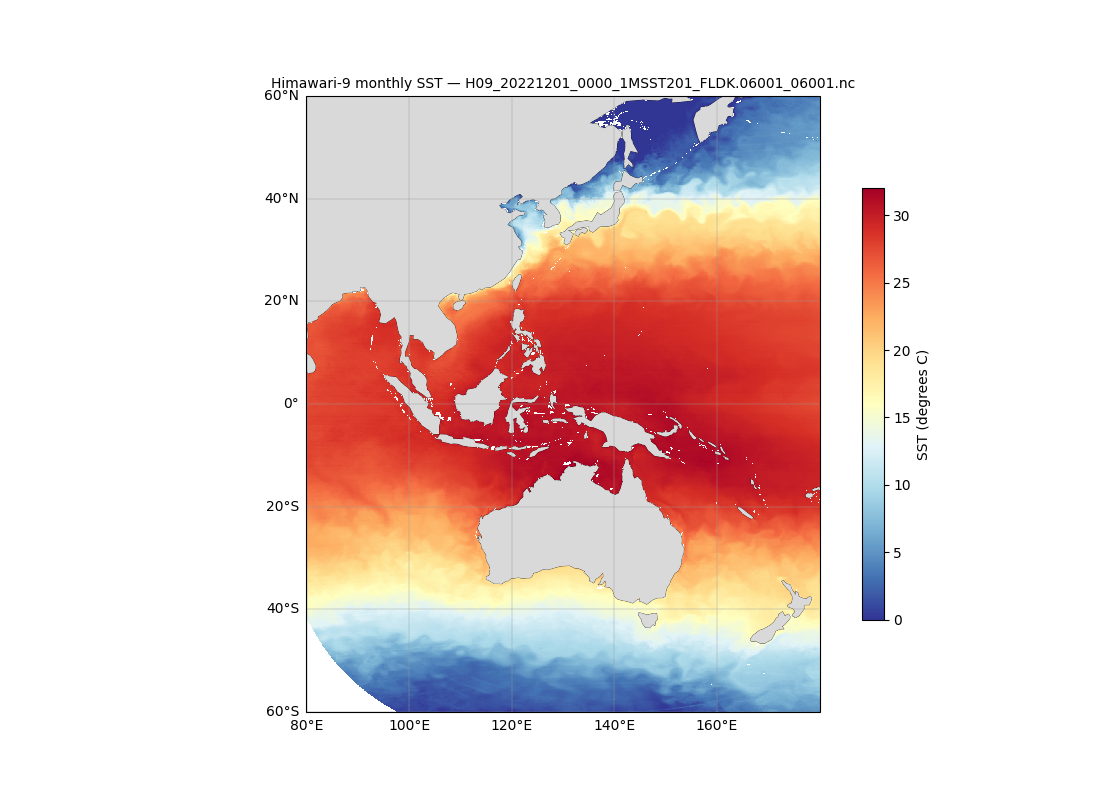

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

DISPLAY_CELLS = 2_000_000        # about what a figure this size can actually show


def for_display(da, max_cells=DISPLAY_CELLS):
    """Subsample a lat/lon grid down to roughly `max_cells`, for drawing only.

    Returns the array unchanged if it is already small enough. Never use the
    result for analysis - subsampling takes every n-th point, it does not
    average, so extremes shift slightly.
    """
    step = int(np.ceil(np.sqrt(da.size / max_cells)))
    if step <= 1:
        return da
    print(f"  subsampling {step}x for display: {da.shape} -> "
          f"({len(da.lat[::step])}, {len(da.lon[::step])})")
    return da.isel(lat=slice(None, None, step), lon=slice(None, None, step))


def image_extent(da, x="lon", y="lat"):
    """Extent and origin for imshow, from a grid of cell-centre coordinates."""
    dx = abs(float(da[x][1] - da[x][0]))
    dy = abs(float(da[y][1] - da[y][0]))
    extent = [float(da[x].min()) - dx / 2, float(da[x].max()) + dx / 2,
              float(da[y].min()) - dy / 2, float(da[y].max()) + dy / 2]
    # Clamp to the globe: an edge past 180 makes cartopy draw the whole world.
    extent = [max(extent[0], -180.0), min(extent[1], 180.0),
              max(extent[2], -90.0), min(extent[3], 90.0)]
    extent = [round(v, 6) for v in extent]
    origin = "upper" if float(da[y][0]) > float(da[y][-1]) else "lower"
    return extent, origin

disc = for_display(sst)
extent, origin = image_extent(disc)

fig, ax = plt.subplots(figsize=(11, 8), subplot_kw={"projection": ccrs.PlateCarree()})
im = ax.imshow(disc.values, extent=extent, origin=origin,
               transform=ccrs.PlateCarree(), interpolation="nearest",
               vmin=0, vmax=32, cmap="RdYlBu_r")
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6")
gl.top_labels = gl.right_labels = False
ax.set_title(f"Himawari-9 monthly SST — {os.path.basename(paths[0])}", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.7, label="SST (degrees C)")

save_fig(fig, "sst_full_disc")
plt.show()

In [8]:
from datetime import datetime


def month_label(nc_path):
    """'H09_20240301_0000_1MSST201_FLDK...' -> 'Mar 2024'."""
    stamp = os.path.basename(nc_path).split("_")[1]
    return datetime.strptime(stamp, "%Y%m%d").strftime("%b %Y")

print("Months loaded:", ", ".join(month_label(p) for p in paths))

Months loaded: Dec 2022, Dec 2023, Jul 2024


## 6. Where is the thermal equator? *(optional)*

Average SST along a band of longitudes and plot it against latitude, and the map becomes a curve whose peak is the **thermal equator**, the latitude of the warmest water.

It is not at 0°. It sits a few degrees **north** on average, because the northern hemisphere holds far more land, and it migrates through the year, trailing the overhead sun by a couple of months. The rain band that follows the warmest water, the **Intertropical Convergence Zone**, moves with it, and that migration is the monsoon that drove the blooms you measured in 2.1.

### Settings you can change

`LON_BAND` sets the band of longitudes averaged. The default, 120°E–160°E, runs through the western Pacific warm pool. Try `(80, 100)`, the Bay of Bengal with land across the north, and `(150, 180)`, open ocean. Every month in `paths` is drawn on the same axes.

### 🔍 What to notice

The peak latitude for each month is printed under the plot. How far does it move between December and July? Look at the shape too: a wide warm tropical plateau, then a sharp fall towards the poles.

Zonal-mean SST over 120E to 160E
  Dec 2022: warmest latitude -11.2°, peak 30.9 degC, at 30°N 21.1, at 30°S 23.0
  Dec 2023: warmest latitude -6.7°, peak 30.5 degC, at 30°N 22.3, at 30°S 25.0
  Jul 2024: warmest latitude +20.5°, peak 30.5 degC, at 30°N 28.9, at 30°S 20.9
Saved figure: output/figures/sst_meridional_profile_120E_160E.png


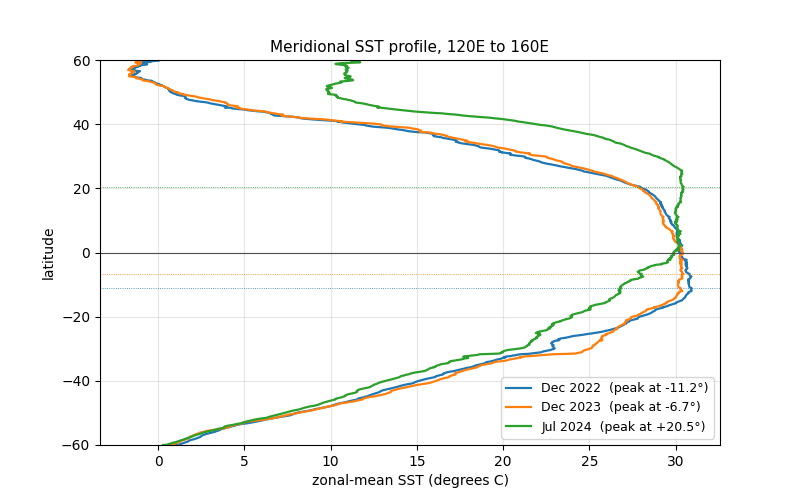

In [9]:
# ── Try changing these ────────────────────────────────────────────────────
LON_BAND = (120, 160)       # degrees E, averaged across this band
# ─────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))
print(f"Zonal-mean SST over {LON_BAND[0]}E to {LON_BAND[1]}E")

for path in paths:
    with xr.open_dataset(path) as d:
        # The band only, and every 5th point in each direction - a profile does
        # not need 0.02 degree resolution, and this keeps the cell quick.
        da = d[sst_var].squeeze(drop=True).sel(lon=slice(*LON_BAND))
        da = da.isel(lat=slice(None, None, 5), lon=slice(None, None, 5)) - 273.15
        profile = da.mean(dim="lon", skipna=True).load()
    peak_lat = float(profile.lat[int(np.nanargmax(profile.values))])
    ax.plot(profile.values, profile.lat, linewidth=1.6,
            label=f"{month_label(path)}  (peak at {peak_lat:+.1f}°)")
    ax.axhline(peak_lat, color=ax.lines[-1].get_color(), linewidth=0.6, linestyle=":")
    print(f"  {month_label(path)}: warmest latitude {peak_lat:+.1f}°, "
          f"peak {float(profile.max()):.1f} degC, "
          f"at 30°N {float(profile.sel(lat=30, method='nearest')):.1f}, "
          f"at 30°S {float(profile.sel(lat=-30, method='nearest')):.1f}")

ax.axhline(0, color="0.3", linewidth=0.8)
ax.set_xlabel("zonal-mean SST (degrees C)")
ax.set_ylabel("latitude")
ax.set_ylim(-60, 60)
ax.set_title(f"Meridional SST profile, {LON_BAND[0]}E to {LON_BAND[1]}E", fontsize=11)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

save_fig(fig, f"sst_meridional_profile_{LON_BAND[0]}E_{LON_BAND[1]}E")
plt.show()

## 7. The tropical Pacific — where ENSO happens

Sections 4 to 6 mapped the Asia-Pacific. Questions 4–7 ask about the **tropical Pacific, 30°S–30°N, 90°E–60°W**.

ENSO is a rearrangement of a whole ocean basin, and what describes it is the **difference between the two ends**: warm water piled against Indonesia in the west, cold upwelled water off South America in the east. You cannot see that without both ends in one map.

The cell draws one map per period, all on the same 23–33 °C scale.

### 🔍 What to look for

Follow the equator across each map: how large is the west-to-east contrast, and how far east does the very warm water reach? Section 8 measures both.

**Himawari stops at 160°W (200°E)** while the region runs to 60°W, so the eastern Pacific, Niño 1+2 included, is off your maps. That is why question 7 leans on the warm pool and the east–west gradient rather than a Niño index.

Loaded periods: 202212, 202312, 202407
Saved figure: output/figures/sst_pacific_202212.png


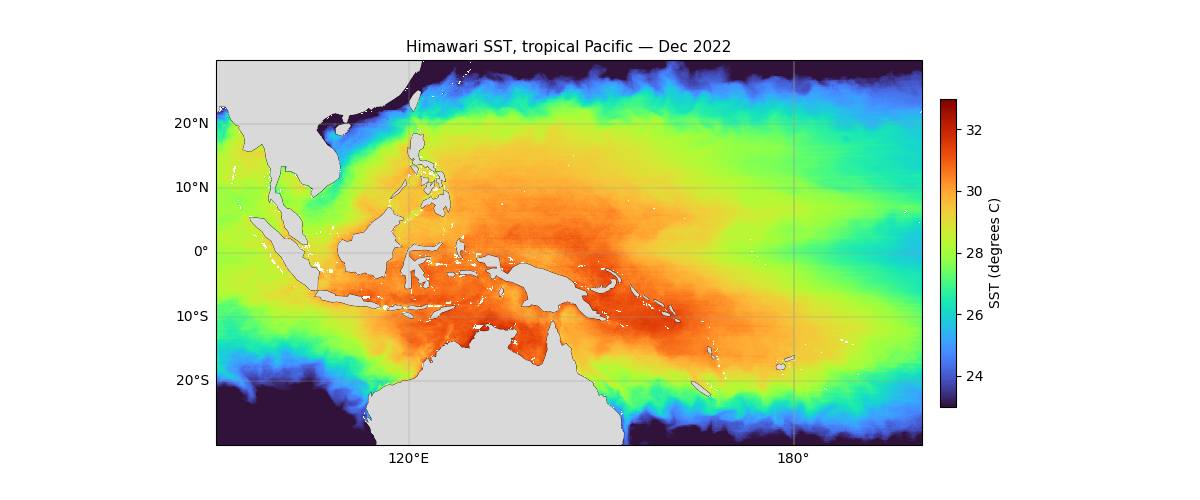

Saved figure: output/figures/sst_pacific_202312.png


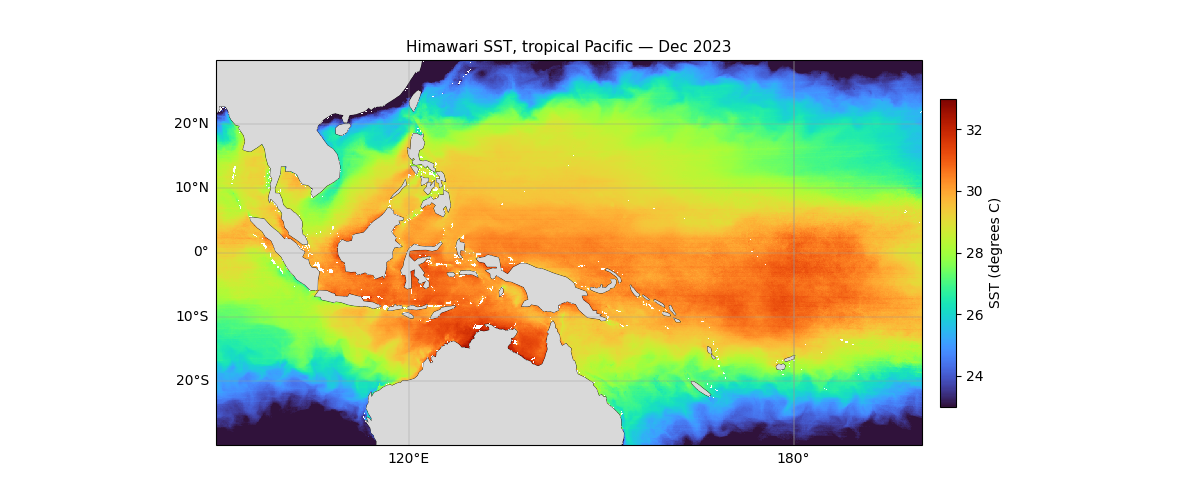

Saved figure: output/figures/sst_pacific_202407.png


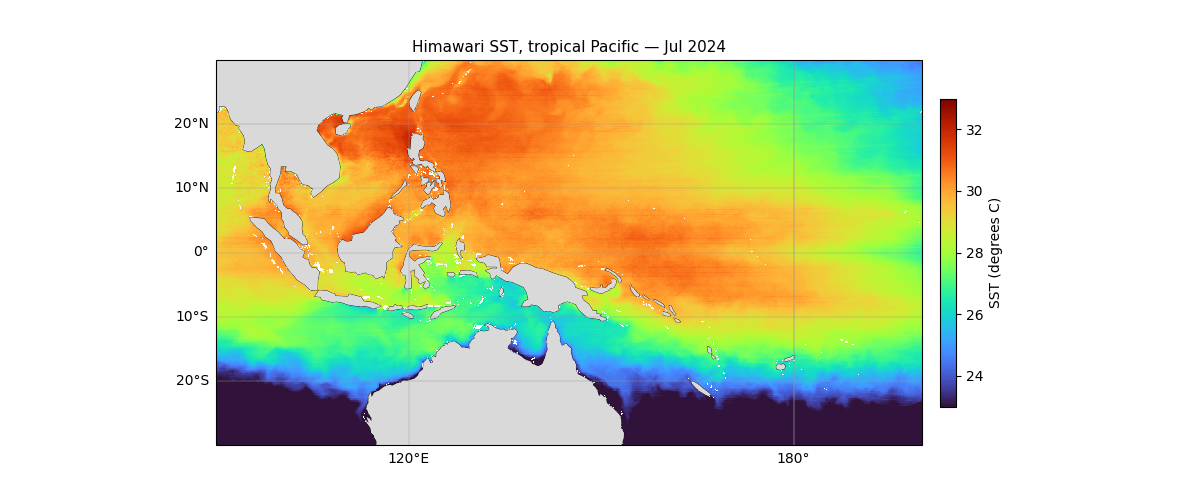

In [10]:
from datetime import datetime

PACIFIC = ccrs.PlateCarree(central_longitude=180)
PACIFIC_EXTENT = [-90, 20, -30, 30]   # 90E to 160W: the overlap of the region
                                      # we want with the disc Himawari can see
SUBSAMPLE = 5                         # every 5th point: 0.02 deg -> 0.1 deg
SST_LIM = (23, 33)                    # degrees C, same for every period


def load_sst_pacific(path, factor=SUBSAMPLE):
    """Monthly SST over the tropical Pacific, in Celsius, on a 0.1 degree grid.

    Crop and subsample *before* the arithmetic. The full disc is 6001 x 6001,
    so converting the whole thing to Celsius first would pull 36 million values
    into memory to throw almost all of them away - the same trap as drawing the
    full-resolution global grid in the PACE notebook.
    """
    with xr.open_dataset(path) as d:
        da = d[sst_var].squeeze(drop=True)
        da = da.sel(lat=slice(30, -30))            # lat runs north to south
        da = da.isel(lat=slice(None, None, factor),
                     lon=slice(None, None, factor))
        da = (da - 273.15).load()                  # Kelvin to Celsius

    da.attrs["units"] = "degrees_Celsius"
    # The lon coordinate wraps past 180, so % 360 re-sorts it and -180 moves
    # it into the frame of a projection centred on 180.
    return da.assign_coords(lon=(da.lon % 360) - 180)


def period_key(nc_path):
    """'H09_20241201_0000_1MSST201_FLDK...' -> '202412'."""
    return os.path.basename(nc_path).split("_")[1][:6]


def period_label(key):
    """'202412' -> 'Dec 2024'."""
    return datetime.strptime(key, "%Y%m").strftime("%b %Y")


def draw_pacific(da, ax, cmap="turbo", vmin=SST_LIM[0], vmax=SST_LIM[1]):
    """Draw one field over the tropical Pacific and return the mappable."""
    im = ax.pcolormesh(da.lon, da.lat, da, transform=PACIFIC,
                       cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    ax.set_extent(PACIFIC_EXTENT, crs=PACIFIC)
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6")
    gl.top_labels = gl.right_labels = False
    return im

# Keyed by period so sections 8 and 9 can pick out what they need.
pacific = {period_key(p): load_sst_pacific(p) for p in paths}
print("Loaded periods:", ", ".join(sorted(pacific)))

for key in sorted(pacific):
    fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": PACIFIC})
    im = draw_pacific(pacific[key], ax)
    ax.set_title(f"Himawari SST, tropical Pacific — {period_label(key)}", fontsize=11)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="SST (degrees C)")
    save_fig(fig, f"sst_pacific_{key}")
    plt.show()

## 8. The warm pool and the cold tongue *(required)*

**Assignment question 7 comes from this cell.**

The trade winds blow east to west along the equator, piling sun-warmed water up in the west as the **warm pool**, the largest body of water above 28 °C on the planet. Above roughly that temperature the air turns unstable enough for deep thunderstorms, so **where the warm pool goes, the rain goes.** At the other end the same winds drag water away from South America and colder water rises to replace it: the **cold tongue**.

In an **El Niño** the trades weaken and the warm pool spreads back towards the middle of the basin, taking the rain with it. In a **La Niña** the trades strengthen and the pattern sharpens.

The cell measures the two numbers that summarise this: **warm-pool area**, and the **east–west equatorial gradient**.

### Settings you can change

- `THRESHOLD` draws a contour and sums the area inside it. 28 °C is the convention; try 29 and 29.5 for the very warm core.
- `LAT_BAND` is the half-width of the equatorial strip used for the profile.

### 🔍 What to notice

Which period has the largest warm pool, and which the smallest west-to-central difference?

**Two caveats.** Himawari stops at 160°W (200°E), so the cold tongue proper is off the right-hand edge. And July is northern summer, so its warm-pool area includes seasonally warm water north of 10°N: compare the two Decembers on area, and use the equatorial profile for all three.

Area of the tropical Pacific (30S-30N, within Himawari's view) above 28.0 degC:
  Dec 2022:  34.3 million km2
  Dec 2023:  39.1 million km2
  Jul 2024:  41.3 million km2

Equatorial SST (2S-2N), west (150-160E) minus east (170-160W):
  Dec 2022: west 30.00, east 26.12, difference +3.88 degC
  Dec 2023: west 30.28, east 29.51, difference +0.76 degC
  Jul 2024: west 30.50, east 27.67, difference +2.83 degC
Saved figure: output/figures/sst_warm_pool_28C_eq2.png


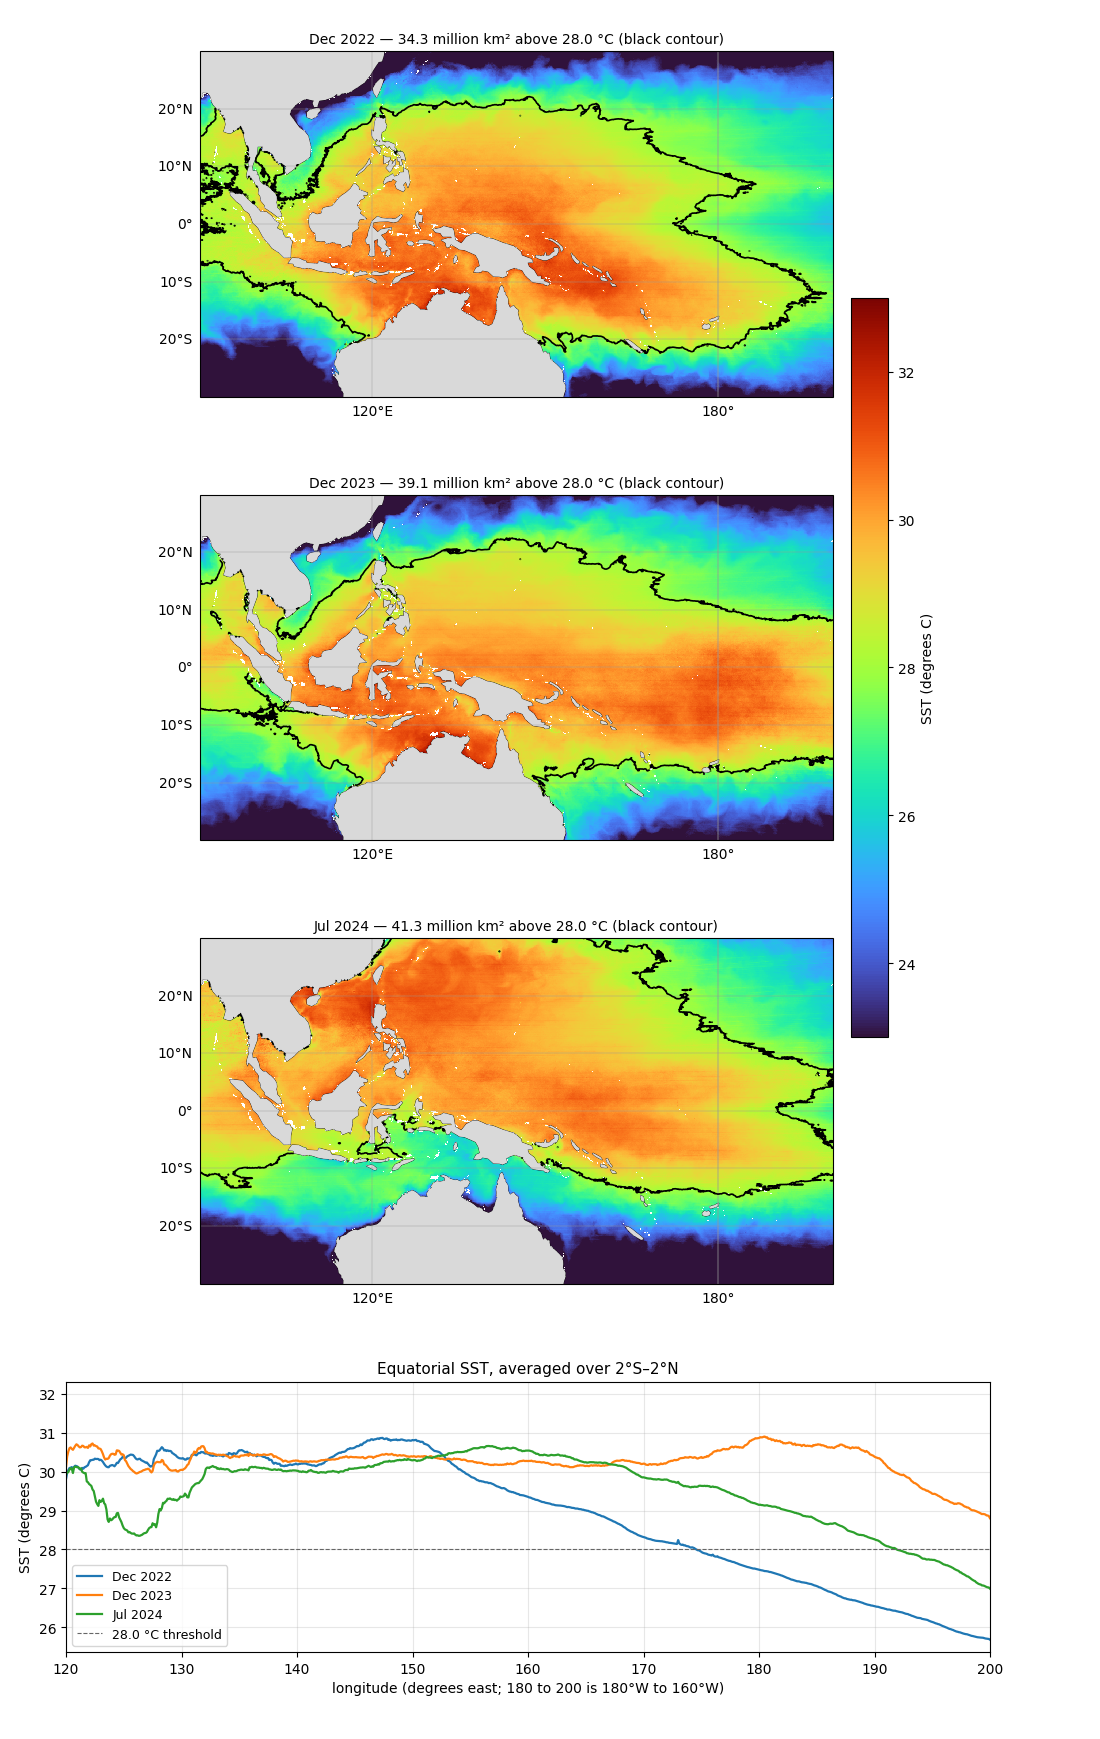

In [11]:
# ── Try changing these ────────────────────────────────────────────────────
THRESHOLD = 28.0        # degrees C - the SST above which deep convection is common
LAT_BAND = 2            # degrees either side of the equator, for the profile
# ─────────────────────────────────────────────────────────────────────────

EARTH_KM = 111.32       # kilometres per degree of latitude


def warm_pool_area(da, threshold):
    # Area above `threshold` in million km^2, weighting each cell by cos(lat).
    dlat = abs(float(da.lat[1] - da.lat[0]))
    dlon = abs(float(da.lon[1] - da.lon[0]))
    cell_km2 = (dlat * EARTH_KM) * (dlon * EARTH_KM * np.cos(np.deg2rad(da.lat)))
    return float(((da > threshold) * cell_km2).sum()) / 1e6

# One map per period with the threshold contour, plus the equatorial profile.
from matplotlib.gridspec import GridSpec

keys = sorted(pacific)
fig = plt.figure(figsize=(11, 4.6 * len(keys) + 3.6))
gs = GridSpec(len(keys) + 1, 1, figure=fig, height_ratios=[4.6] * len(keys) + [3.6],
              hspace=0.3, left=0.06, right=0.9, top=0.97, bottom=0.05)
map_axes = [fig.add_subplot(gs[i], projection=PACIFIC) for i in range(len(keys))]
ax_prof = fig.add_subplot(gs[-1])

print(f"Area of the tropical Pacific (30S-30N, within Himawari's view) above {THRESHOLD} degC:")
for ax, key in zip(map_axes, keys):
    da = pacific[key]
    im = draw_pacific(da, ax)
    ax.contour(da.lon, da.lat, da, levels=[THRESHOLD], colors="k", linewidths=1.2,
               transform=PACIFIC)
    area = warm_pool_area(da, THRESHOLD)
    # y=1.0 places the title explicitly: with labelled gridlines, cartopy's
    # automatic title position can end up off the top of a stacked figure.
    ax.set_title(f"{period_label(key)} — {area:.1f} million km² above {THRESHOLD} °C "
                 f"(black contour)", fontsize=10, y=1.0, pad=6)
    print(f"  {period_label(key)}: {area:5.1f} million km2")

    # Equatorial profile: average the strip, then plot against longitude in
    # degrees east (the lon coordinate is in the projection's frame, 180 = 0).
    strip = da.sel(lat=slice(LAT_BAND, -LAT_BAND)).mean(dim="lat", skipna=True)
    lon_east = strip.lon.values + 180
    ax_prof.plot(lon_east, strip.values, linewidth=1.6, label=period_label(key))

fig.colorbar(im, ax=map_axes, shrink=0.6, pad=0.02, label="SST (degrees C)")

ax_prof.axhline(THRESHOLD, color="0.4", linewidth=0.8, linestyle="--",
                label=f"{THRESHOLD} °C threshold")
ax_prof.set_xlabel("longitude (degrees east; 180 to 200 is 180°W to 160°W)")
ax_prof.set_ylabel("SST (degrees C)")
ax_prof.set_title(f"Equatorial SST, averaged over {LAT_BAND}°S–{LAT_BAND}°N", fontsize=11)
ax_prof.set_xlim(120, 200)
ax_prof.grid(alpha=0.3)
ax_prof.legend(fontsize=9)

# The east-west gradient as one number per period: the western warm pool
# against the easternmost part of the disc.
print(f"\nEquatorial SST ({LAT_BAND}S-{LAT_BAND}N), west (150-160E) minus east (170-160W):")
for key in keys:
    strip = pacific[key].sel(lat=slice(LAT_BAND, -LAT_BAND)).mean(dim="lat", skipna=True)
    west = float(strip.sel(lon=slice(150 - 180, 160 - 180)).mean())
    east = float(strip.sel(lon=slice(190 - 180, 200 - 180)).mean())
    print(f"  {period_label(key)}: west {west:.2f}, east {east:.2f}, difference {west - east:+.2f} degC")

save_fig(fig, f"sst_warm_pool_{THRESHOLD:g}C_eq{LAT_BAND}")
plt.show()

> ### 📝 For your Word document (2.2 §8 — required)
>
> Keep the figure for `THRESHOLD = 28`, and the two printed tables, the warm-pool areas, and the west-minus-east differences.
>
> [Assignment question 7](https://github.com/earthobservatory/eyes-on-earth-tutorials-public/blob/main/2.0_Tutorial_2_Overview_and_Assignment/README.md#part-b--analyse-the-ocean) in the handout says what to write.

## 9. The difference between periods *(after the session)*

**Leave this section for after the session.** The cell needs the answer to assignment question 4, which of your three periods is neutral, which El Niño and which La Niña, and that comes from a published ENSO index, not from these maps.

**Nothing from this section is handed in.** It is here so you can check your question 5 answer against the data: if you have the phases right, each difference map looks like its phase.

Your three maps look almost identical, because each is dominated by the same equator-to-pole gradient with the ENSO signal a degree or two on top. **Subtracting one period from another removes what they share and leaves what changed.**

### Fill this in before you run the cell

Set `LA_NINA`, `EL_NINO` and `NEUTRAL` to the period keys. Leave any as `None` and the cell stops with an error naming the periods that are loaded.

### 🔍 How to read the maps

- **Red means the first period was warmer.** Both differences are written *phase minus neutral*.
- **Answer from the 15°S–15°N band only.** Outside it the seasonal cycle dwarfs the ENSO signal, and `FOCUS_LAT` crops to the band.
- If a map looks like the *opposite* of its phase, check you have not swapped two keys.

Two settings worth trying: `DIFF_LIM = 8` against `3`, and `FOCUS_LAT = 15` against `None`.

In [12]:
# ── Try changing these ────────────────────────────────────────────────────
DIFF_LIM = 8.0        # degrees C, symmetric about zero - try 3 for the tropics
FOCUS_LAT = None      # e.g. 15 to crop to 15S-15N; None for the whole disc
# ─────────────────────────────────────────────────────────────────────────

# --- Fill this in --------------------------------------------------------
# Assign each period to its ENSO phase, from a published index rather than
# from these maps. That is question 4. The keys are "202212", "202312", "202407".
LA_NINA = None
EL_NINO = None
NEUTRAL = None
# -------------------------------------------------------------------------

assigned = {"La Nina": LA_NINA, "El Nino": EL_NINO, "neutral": NEUTRAL}
loaded = ", ".join(sorted(pacific))

if None in assigned.values():
    raise ValueError(
        "Assign LA_NINA, EL_NINO and NEUTRAL above before running this cell - "
        f"one period each, from those section 7 loaded: {loaded}.")

if len(set(assigned.values())) != 3:
    raise ValueError(
        f"Each period belongs to exactly one phase, but you have: {assigned}")

unknown = sorted(set(assigned.values()) - set(pacific))
if unknown:
    raise ValueError(
        f"No SST loaded for {', '.join(unknown)}. Section 7 has: {loaded}. "
        "Check the spelling, or re-run the download in section 2.")

# Both differences are taken against the neutral period, so what survives the
# subtraction is the ENSO signal rather than the season.
DIFFS = [(LA_NINA, NEUTRAL, "La Nina minus neutral"),
         (EL_NINO, NEUTRAL, "El Nino minus neutral")]

for first, second, phase in DIFFS:
    # Same grid, so this is a straight cell-by-cell subtraction.
    diff = pacific[first] - pacific[second]
    if FOCUS_LAT is not None:
        diff = diff.sel(lat=slice(FOCUS_LAT, -FOCUS_LAT))   # lat runs north to south

    fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": PACIFIC})
    im = draw_pacific(diff, ax, cmap="RdBu_r", vmin=-DIFF_LIM, vmax=DIFF_LIM)
    if FOCUS_LAT is not None:
        ax.set_extent(PACIFIC_EXTENT[:2] + [-FOCUS_LAT, FOCUS_LAT], crs=PACIFIC)
    band = diff.sel(lat=slice(15, -15))
    print(f"{phase}: mean difference 15S-15N {float(band.mean()):+.2f} degC, "
          f"range {float(band.min()):+.1f} to {float(band.max()):+.1f}")
    ax.set_title(f"SST difference — {period_label(first)} minus "
                 f"{period_label(second)}  ({phase})", fontsize=11)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02,
                 label="Difference in SST (degrees C)")
    save_fig(fig, f"sst_diff_{first}_{second}_lim{DIFF_LIM:g}" + (f"_lat{FOCUS_LAT}" if FOCUS_LAT else ""))
    plt.show()

ValueError: Assign LA_NINA, EL_NINO and NEUTRAL above before running this cell - one period each, from those section 7 loaded: 202212, 202312, 202407.